## LIME explanations for a regression task

In [1]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
import sklearn.ensemble
import lime
import lime.lime_tabular
np.random.seed(1)

In [4]:
data = pd.read_csv("data/insurance.csv")

In [5]:
data.head()

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


In [6]:
X = data.drop(['charges'],axis=1)
y = data['charges']

In [7]:
train, test, labels_train, labels_test = sklearn.model_selection.train_test_split(X, y, train_size=0.80, test_size=0.20)

# Handling missing values
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
train_imputed = imp_mean.fit_transform(train)

# Standardize the training data-clf-students
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_imputed)
train_scaled


array([[0.76086957, 0.        , 0.28625235, 0.        , 0.        ],
       [0.76086957, 1.        , 0.14635459, 0.2       , 0.        ],
       [0.        , 1.        , 0.57384988, 0.        , 0.        ],
       ...,
       [0.7173913 , 0.        , 0.51116492, 0.4       , 1.        ],
       [0.47826087, 0.        , 0.16841539, 0.4       , 1.        ],
       [0.84782609, 1.        , 0.32230293, 0.2       , 0.        ]],
      shape=(1070, 5))

In [13]:
# Handling missing values
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
train_imputed = imp_mean.fit_transform(train)

# Standardize the training data-clf-students
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_imputed)
train_scaled

array([[0.76086957, 0.        , 0.28625235, 0.        , 0.        ],
       [0.76086957, 1.        , 0.14635459, 0.2       , 0.        ],
       [0.        , 1.        , 0.57384988, 0.        , 0.        ],
       ...,
       [0.7173913 , 0.        , 0.51116492, 0.4       , 1.        ],
       [0.47826087, 0.        , 0.16841539, 0.4       , 1.        ],
       [0.84782609, 1.        , 0.32230293, 0.2       , 0.        ]])

In [8]:
# Handling missing values
test_imputed = imp_mean.transform(test)

# Standardize the training data-clf-students
test_scaled = scaler.transform(test_imputed)


In [9]:
# Train a random forest 
rf = sklearn.ensemble.RandomForestRegressor(n_estimators=1000, random_state=42)
rf.fit(train_scaled, labels_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [10]:
r2 = r2_score(labels_test, rf.predict(test_scaled))
print("Model evaluation (R2): ",r2)

Model evaluation (R2):  0.8481471326027317


In [11]:
categorical_features = [1,3,4]

In [12]:
# Generates the explanation
explainer = lime.lime_tabular.LimeTabularExplainer(train_scaled, 
                                                   feature_names=X.columns, 
                                                   class_names=['charges'], 
                                                   categorical_features=categorical_features, 
                                                   verbose=True, 
                                                   mode='regression')

In [13]:
# Handling missing values
test_imputed = imp_mean.transform(test)

# Standardize the training data-clf-students
test_scaled = scaler.transform(test_imputed)


In [14]:
i = 1
exp1 = explainer.explain_instance(test_scaled[i], rf.predict, num_features=4)

Intercept 31051.570818454697
Prediction_local [14566.62619778]
Right: 12952.622389400056


In [16]:
exp1.show_in_notebook(show_all=True)

ImportError: cannot import name 'display' from 'IPython.core.display' (/Users/daanwichmann/PycharmProjects/Explainable AI/.venv/lib/python3.13/site-packages/IPython/core/display.py)

In [17]:
# Coefficients of the local model
exp1.as_list()

[('smoker=0', -23955.32602577632),
 ('age > 0.72', 7208.359916145673),
 ('0.39 < bmi <= 0.50', 1515.0460670632594),
 ('children=0', -1253.024578107975)]

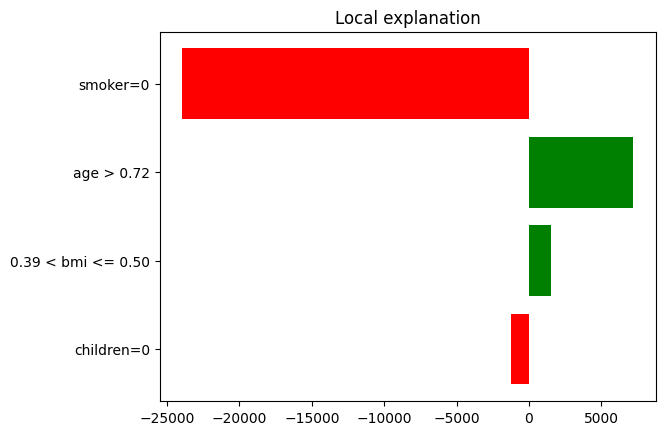

In [18]:
# alternative way to plot
%matplotlib inline
fig = exp1.as_pyplot_figure()

### Explaining another instance

In [33]:
i = 5
exp1 = explainer.explain_instance(test_scaled[i], rf.predict, num_features=4)

Intercept 8582.610190252895
Prediction_local [32368.93965785]
Right: 38542.817227099855


In [34]:
# Coefficients of the local model
exp1.as_list()

[('smoker=1', 23232.44065967206),
 ('0.20 < age <= 0.46', -2988.444103556693),
 ('0.39 < bmi <= 0.50', 2429.3388858745993),
 ('children=0', 1112.9940256120442)]

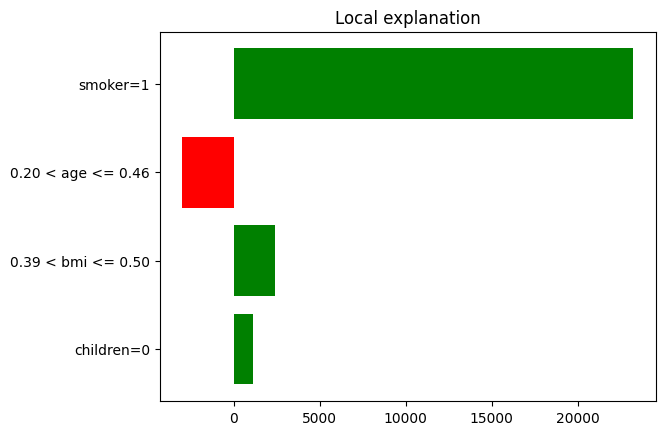

In [35]:
# alternative way to plot
%matplotlib inline
fig = exp1.as_pyplot_figure()

### Explanation using only one factor

In [49]:
categorical_features = [1,3,4]

In [50]:
# Handling missing values
test_imputed = imp_mean.transform(test)

# Standardize the training data-clf-students
test_scaled = scaler.transform(test_imputed)


In [51]:
# Generates the explanation
explainer = lime.lime_tabular.LimeTabularExplainer(train_scaled, 
                                                   feature_names=X.columns, 
                                                   class_names=['charges'], 
                                                   categorical_features=categorical_features, 
                                                   verbose=True, 
                                                   mode='regression')

In [52]:
i = 5
exp1 = explainer.explain_instance(test_scaled[i], rf.predict, num_features=1)

Intercept 8617.60481816418
Prediction_local [32322.9150948]
Right: 38542.817227099855


In [53]:
# Coefficients of the local model
exp1.as_list()

[('smoker=1', 23705.31027663904)]

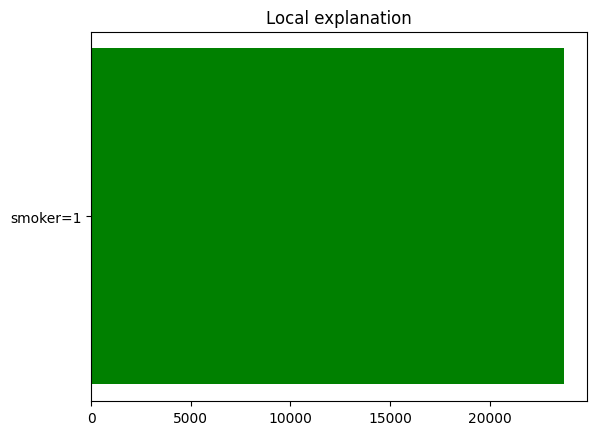

In [54]:
# alternative way to plot
%matplotlib inline
fig = exp1.as_pyplot_figure()